# Smart Energy Optimizer — Unusual Consumption Events

Use forecast residuals to rank unusual deviations. Results are anomaly candidates, not confirmed anomalies.

## 1. Load forecast residuals

Validation residuals calibrate the detector. Test residuals are scored with the same fixed rules.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROCESSED = ROOT / 'data/processed'
OUTPUTS = ROOT / 'outputs'
FIGURES = ROOT / 'reports/figures'
FIGURES.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:.4f}'.format

In [2]:
residuals = pd.read_parquet(PROCESSED / 'forecasting_predictions.parquet')
residuals = residuals.rename(columns={
    'energy_kwh': 'actual_consumption',
    'predicted_kwh': 'predicted_consumption',
})
residuals['slot'] = residuals.timestamp.dt.hour * 2 + residuals.timestamp.dt.minute // 30
residuals['hour'] = residuals['slot'] / 2
residuals['day_of_week'] = residuals.timestamp.dt.dayofweek
residuals['weekend'] = residuals.day_of_week.ge(5)

summary = residuals.groupby('split').agg(
    first_timestamp=('timestamp', 'min'), last_timestamp=('timestamp', 'max'),
    households=('household_id', 'nunique'), rows=('timestamp', 'size'),
    mean_residual=('residual', 'mean'), mean_absolute_error=('absolute_error', 'mean'))
display(summary)
display(residuals.isna().sum().to_frame('missing'))

,first_timestamp,last_timestamp,households,rows,mean_residual,mean_absolute_error
split,,,,,,
test,2013-11-01,2013-12-31 23:30:00,23,67304,0.0586,0.1244
validation,2013-09-01,2013-10-31 23:30:00,24,68685,0.0391,0.0834


,missing
household_id,0
timestamp,0
forecast_origin,0
split,0
actual_consumption,0
predicted_consumption,0
residual,0
absolute_error,0
slot,0
hour,0


An unusual event is a large difference between observed and expected consumption. It may come from behavior, a forecast error or a data issue.

## 2. Residual distributions

Positive residual means higher consumption than predicted. Negative residual means lower consumption than predicted.

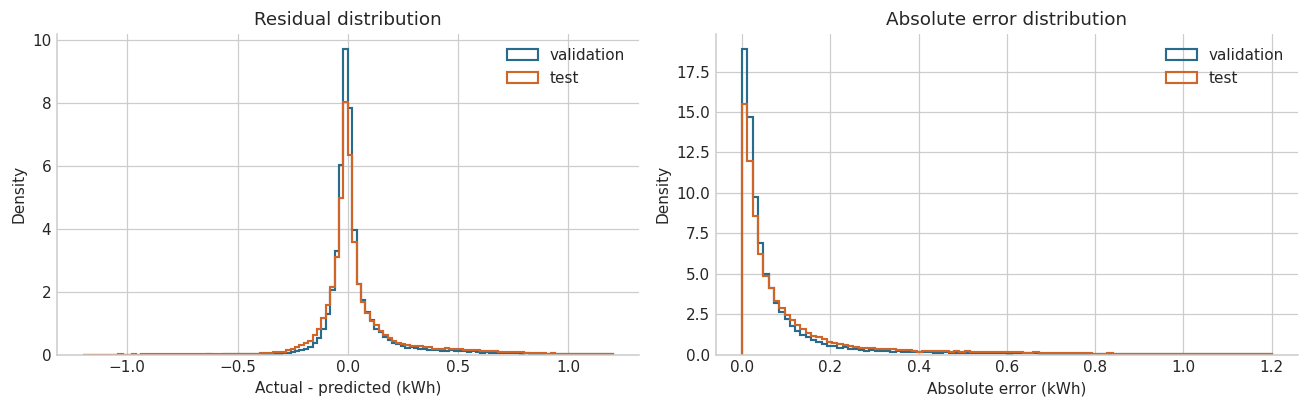

,mean,median,std,min,max
split,,,,,
test,0.0586,0.0011,0.2500,-1.2153,5.0032
validation,0.0391,0.0001,0.1673,-0.8865,2.3736


,0.5000,0.9000,0.9500,0.9900,0.9950
split,,,,,
test,0.0475,0.3214,0.5440,1.1040,1.4344
validation,0.0337,0.1937,0.3545,0.7669,0.9546


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for split, color in [('validation', '#286b8a'), ('test', '#d0652a')]:
    data = residuals.loc[residuals.split.eq(split)]
    axes[0].hist(data.residual, bins=120, range=(-1.2, 1.2), density=True,
                 histtype='step', linewidth=1.4, label=split, color=color)
    axes[1].hist(data.absolute_error, bins=100, range=(0, 1.2), density=True,
                 histtype='step', linewidth=1.4, label=split, color=color)
axes[0].set(title='Residual distribution', xlabel='Actual - predicted (kWh)', ylabel='Density')
axes[1].set(title='Absolute error distribution', xlabel='Absolute error (kWh)', ylabel='Density')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_01_residual_distributions.png', dpi=140, bbox_inches='tight')
plt.show()

display(residuals.groupby('split').residual.agg(['mean', 'median', 'std', 'min', 'max']))
display(residuals.groupby('split').absolute_error.quantile([.5, .9, .95, .99, .995]).unstack())

Test residuals have a wider tail. This agrees with the higher winter forecast error, so the test alert rate may exceed the calibration rate.

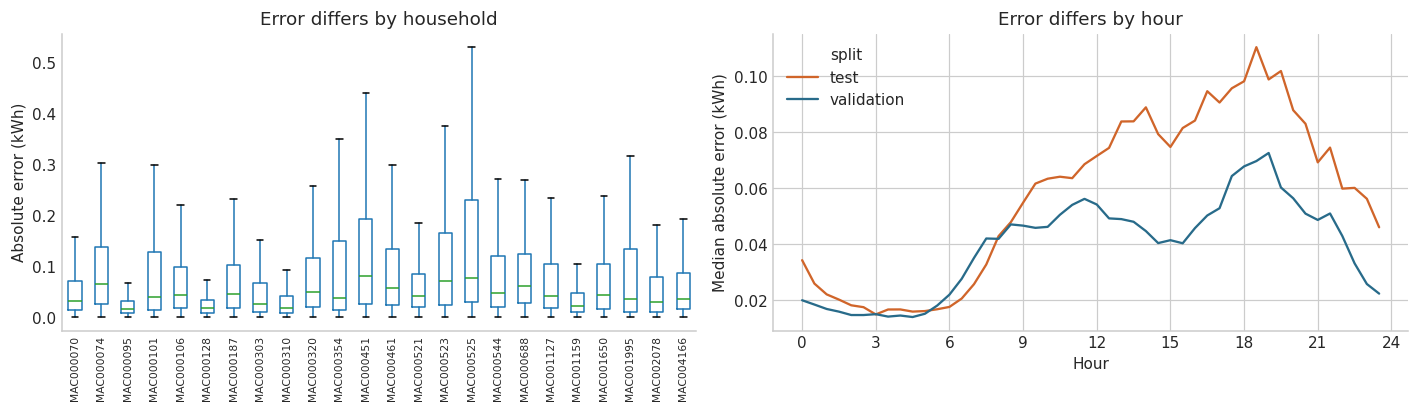

weekend,False,True
split,,
test,0.1222,0.1296
validation,0.0805,0.0910


In [4]:
household_order = residuals.groupby('household_id').absolute_error.median().sort_values().index
slot_error = residuals.groupby(['split', 'hour']).absolute_error.median().unstack(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
residuals.boxplot(column='absolute_error', by='household_id', ax=axes[0],
                  showfliers=False, grid=False, rot=90)
axes[0].set(title='Error differs by household', xlabel='', ylabel='Absolute error (kWh)')
axes[0].tick_params(axis='x', labelsize=7)
slot_error.plot(ax=axes[1], color=['#d0652a', '#286b8a'])
axes[1].set(title='Error differs by hour', xlabel='Hour', ylabel='Median absolute error (kWh)', xticks=range(0, 25, 3))
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_02_group_errors.png', dpi=140, bbox_inches='tight')
plt.show()

display(residuals.groupby(['split', 'weekend']).absolute_error.mean().unstack())

Error levels differ strongly across households and hours. One raw global threshold can favor households with larger normal errors.

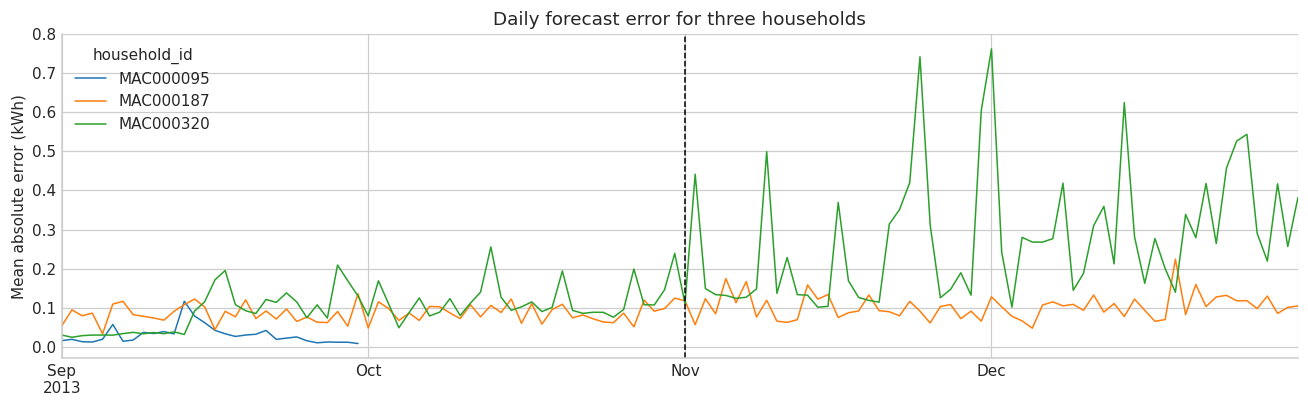

In [5]:
chosen_households = residuals.groupby('household_id').absolute_error.mean().sort_values().index[[0, 11, -1]]
daily_error = residuals.loc[residuals.household_id.isin(chosen_households)].assign(
    day=lambda x: x.timestamp.dt.floor('D')
).groupby(['day', 'household_id']).absolute_error.mean().unstack()

fig, ax = plt.subplots(figsize=(12, 3.8))
daily_error.plot(ax=ax, linewidth=1)
ax.axvline(pd.Timestamp('2013-11-01'), color='black', linestyle='--', linewidth=1)
ax.set(title='Daily forecast error for three households', xlabel='', ylabel='Mean absolute error (kWh)')
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_03_residuals_through_time.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Leakage-safe robust score

For each household, fit the residual median and MAD on validation only. Every household has enough calibration rows, so no fallback is needed.

In [6]:
validation = residuals.loc[residuals.split.eq('validation')].copy()
calibration_rows = []
for household, data in validation.groupby('household_id'):
    median = data.residual.median()
    mad = (data.residual - median).abs().median()
    calibration_rows.append({
        'household_id': household,
        'calibration_rows': len(data),
        'residual_median': median,
        'residual_scale': 1.4826 * mad,
    })
calibration = pd.DataFrame(calibration_rows)
assert calibration.residual_scale.gt(0).all()

scored = residuals.merge(calibration, on='household_id', how='left', validate='many_to_one')
scored['anomaly_score'] = (
    (scored.residual - scored.residual_median).abs() / scored.residual_scale
)
scored['anomaly_direction'] = np.where(
    scored.residual.ge(0), 'higher_than_expected', 'lower_than_expected'
)
display(calibration.describe())

,calibration_rows,residual_median,residual_scale
count,24.0000,24.0000,24.0000
mean,2861.8750,0.0008,0.0559
std,313.3576,0.0046,0.0253
min,1391.0000,-0.0078,0.0210
25%,2926.7500,-0.0028,0.0376
50%,2928.0000,0.0006,0.0545
75%,2928.0000,0.0029,0.0656
max,2928.0000,0.0105,0.1178


The score is the distance from the household's normal residual, measured in robust scale units. A larger score means a more unusual deviation for that household.

## 4. Global versus household normalization

Compare both methods at the same 0.5% validation alert rate.

,method,test_alerts,test_alert_rate,households_flagged,largest_household_share
0,Global absolute error,918,0.0136,23,0.3126
1,Household robust score,1014,0.0151,22,0.2781


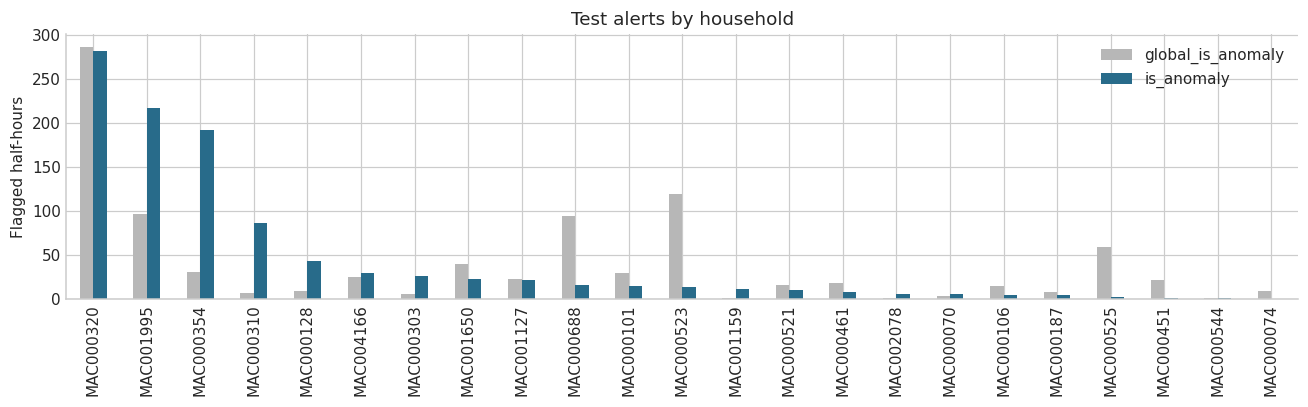

In [7]:
global_threshold = validation.absolute_error.quantile(.995)
robust_threshold = scored.loc[scored.split.eq('validation'), 'anomaly_score'].quantile(.995)
scored['global_is_anomaly'] = scored.absolute_error.ge(global_threshold)
scored['is_anomaly'] = scored.anomaly_score.ge(robust_threshold)

comparison_rows = []
for name, column in [('Global absolute error', 'global_is_anomaly'),
                     ('Household robust score', 'is_anomaly')]:
    test_flags = scored.loc[scored.split.eq('test') & scored[column]]
    counts = test_flags.groupby('household_id').size()
    comparison_rows.append({
        'method': name,
        'test_alerts': len(test_flags),
        'test_alert_rate': len(test_flags) / scored.split.eq('test').sum(),
        'households_flagged': len(counts),
        'largest_household_share': counts.max() / counts.sum(),
    })
normalization_comparison = pd.DataFrame(comparison_rows)
display(normalization_comparison)

flag_counts = scored.loc[scored.split.eq('test')].groupby('household_id')[
    ['global_is_anomaly', 'is_anomaly']
].sum().sort_values('is_anomaly', ascending=False)
flag_counts.plot.bar(figsize=(12, 3.8), color=['#b7b7b7', '#286b8a'])
plt.title('Test alerts by household')
plt.xlabel('')
plt.ylabel('Flagged half-hours')
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_04_normalization_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

Household normalization reduces the effect of different consumption scales. Hourly errors still vary, but adding small time groups would make the detector harder to explain.

## 5. Select an alert threshold

Compare three validation alert rates. Thresholds are fitted on validation and applied unchanged to test.

,validation_target_rate,threshold,split,flagged_points,alert_rate,households_flagged,largest_household_share
0,0.0050,18.4176,validation,344,0.0050,18,0.2326
1,0.0050,18.4176,test,1014,0.0151,22,0.2781
2,0.0100,14.0355,validation,687,0.0100,21,0.1718
3,0.0100,14.0355,test,1841,0.0274,23,0.2319
4,0.0200,10.3670,validation,1374,0.0200,24,0.1121
5,0.0200,10.3670,test,3139,0.0466,23,0.1940


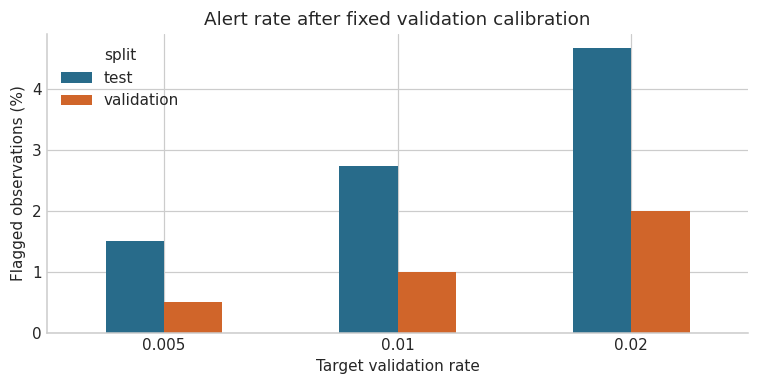

In [8]:
threshold_rows = []
for expected_rate in [.005, .01, .02]:
    threshold = scored.loc[scored.split.eq('validation'), 'anomaly_score'].quantile(1 - expected_rate)
    for split in ['validation', 'test']:
        data = scored.loc[scored.split.eq(split)]
        flags = data.anomaly_score.ge(threshold)
        counts = data.loc[flags].groupby('household_id').size()
        threshold_rows.append({
            'validation_target_rate': expected_rate,
            'threshold': threshold,
            'split': split,
            'flagged_points': flags.sum(),
            'alert_rate': flags.mean(),
            'households_flagged': len(counts),
            'largest_household_share': counts.max() / counts.sum(),
        })
threshold_comparison = pd.DataFrame(threshold_rows)
display(threshold_comparison)

pivot = threshold_comparison.pivot(index='validation_target_rate', columns='split', values='alert_rate') * 100
pivot.plot.bar(figsize=(7, 3.6), color=['#286b8a', '#d0652a'])
plt.title('Alert rate after fixed validation calibration')
plt.xlabel('Target validation rate')
plt.ylabel('Flagged observations (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_05_threshold_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

Select the 0.5% validation rate. It gives a robust-score threshold of **18.42** and a cautious alert volume without using test data to choose the cutoff.

In [9]:
selected_threshold = robust_threshold
scored['is_anomaly'] = scored.anomaly_score.ge(selected_threshold)
direction_summary = scored.loc[scored.is_anomaly].groupby(
    ['split', 'anomaly_direction']
).size().unstack(fill_value=0)
direction_summary['total'] = direction_summary.sum(axis=1)
direction_summary['positive_share'] = direction_summary['higher_than_expected'] / direction_summary['total']
display(direction_summary)

anomaly_direction,higher_than_expected,lower_than_expected,total,positive_share
split,,,,
test,979,35,1014,0.9655
validation,344,0,344,1.0000


## 6. Group consecutive alerts

Consecutive flagged half-hours from one household form one episode. This avoids repeated dashboard alerts for the same event.

In [10]:
flagged = scored.loc[scored.is_anomaly].sort_values(['split', 'household_id', 'timestamp']).copy()
new_episode = (
    flagged.household_id.ne(flagged.household_id.shift())
    | flagged['split'].ne(flagged['split'].shift())
    | flagged.timestamp.diff().ne(pd.Timedelta(minutes=30))
)
flagged['episode_id'] = new_episode.cumsum()

episode_rows = []
for _, data in flagged.groupby('episode_id'):
    peak = data.loc[data.anomaly_score.idxmax()]
    episode_rows.append({
        'household_id': data.household_id.iloc[0],
        'split': data['split'].iloc[0],
        'episode_start': data.timestamp.min(),
        'episode_end': data.timestamp.max(),
        'duration_slots': len(data),
        'max_anomaly_score': data.anomaly_score.max(),
        'max_absolute_error': data.absolute_error.max(),
        'direction': peak.anomaly_direction,
    })
episodes = pd.DataFrame(episode_rows).sort_values('max_anomaly_score', ascending=False)
display(episodes.groupby('split').agg(
    episodes=('household_id', 'size'),
    multi_point_episodes=('duration_slots', lambda x: x.gt(1).sum()),
    longest_episode=('duration_slots', 'max')))
display(episodes.loc[episodes.split.eq('test')].head(10))

,episodes,multi_point_episodes,longest_episode
split,,,
test,566,176,13
validation,268,56,6


,household_id,split,episode_start,episode_end,duration_slots,max_anomaly_score,max_absolute_error,direction
217,MAC000320,test,2013-12-14 17:30:00,2013-12-14 22:30:00,11,92.7791,5.0032,higher_than_expected
164,MAC000320,test,2013-11-16 18:00:00,2013-11-16 21:00:00,7,89.2536,4.8129,higher_than_expected
193,MAC000320,test,2013-11-30 19:00:00,2013-11-30 23:00:00,9,88.6150,4.7785,higher_than_expected
240,MAC000320,test,2013-12-25 18:30:00,2013-12-25 20:00:00,4,86.1796,4.6470,higher_than_expected
232,MAC000320,test,2013-12-22 16:00:00,2013-12-22 18:00:00,5,78.7436,4.2457,higher_than_expected
535,MAC001995,test,2013-12-25 14:00:00,2013-12-25 16:30:00,6,75.8700,2.8971,higher_than_expected
22,MAC000128,test,2013-11-03 10:00:00,2013-11-03 10:00:00,1,73.5276,1.7586,higher_than_expected
205,MAC000320,test,2013-12-07 16:30:00,2013-12-07 16:30:00,1,68.4099,3.6881,higher_than_expected
243,MAC000320,test,2013-12-26 17:00:00,2013-12-26 17:00:00,1,65.6919,3.5414,higher_than_expected
36,MAC000128,test,2013-11-24 10:30:00,2013-11-24 10:30:00,1,64.3778,1.5396,higher_than_expected


## 7. Review candidates in context

Show the strongest positive deviation, strongest negative deviation and longest test episode. The plots do not prove their cause.

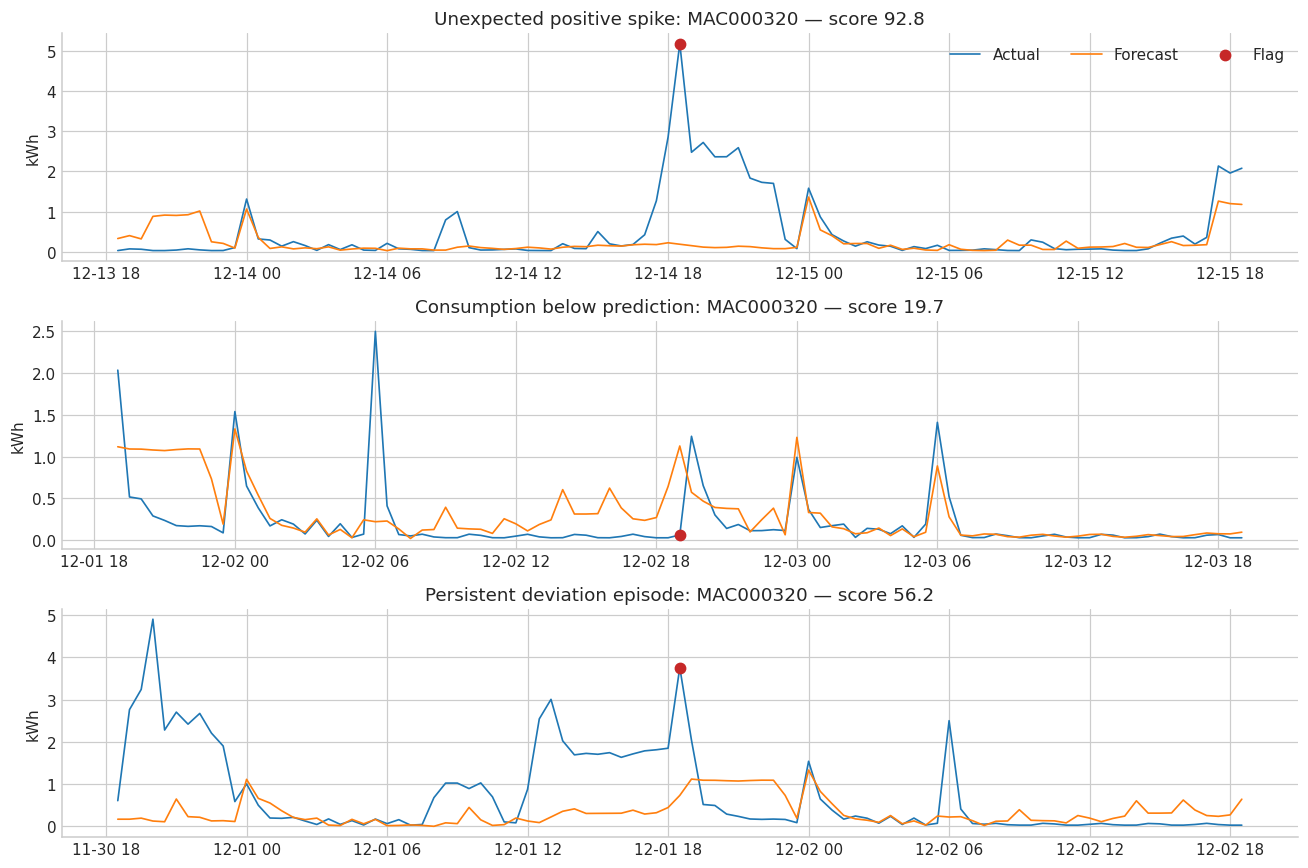

In [11]:
test_flags = scored.loc[scored.split.eq('test') & scored.is_anomaly]
positive_event = test_flags.loc[test_flags.residual.idxmax()]
negative_event = test_flags.loc[test_flags.residual.idxmin()]
longest_test_episode = episodes.loc[episodes.split.eq('test')].sort_values(
    ['duration_slots', 'max_anomaly_score'], ascending=False
).iloc[0]
long_event = test_flags.loc[
    test_flags.household_id.eq(longest_test_episode.household_id)
    & test_flags.timestamp.between(longest_test_episode.episode_start, longest_test_episode.episode_end)
].sort_values('anomaly_score').iloc[-1]

events = [
    ('Unexpected positive spike', positive_event),
    ('Consumption below prediction', negative_event),
    ('Persistent deviation episode', long_event),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
for ax, (label, event) in zip(axes, events):
    start = event.timestamp - pd.Timedelta(hours=24)
    end = event.timestamp + pd.Timedelta(hours=24)
    context = scored.loc[
        scored.household_id.eq(event.household_id) & scored.timestamp.between(start, end)
    ]
    ax.plot(context.timestamp, context.actual_consumption, label='Actual', linewidth=1.1)
    ax.plot(context.timestamp, context.predicted_consumption, label='Forecast', linewidth=1.1)
    ax.scatter([event.timestamp], [event.actual_consumption], color='#c62828', s=45, zorder=4, label='Flag')
    ax.set_title(f'{label}: {event.household_id} — score {event.anomaly_score:.1f}')
    ax.set_ylabel('kWh')
axes[0].legend(ncol=3)
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_06_event_context.png', dpi=140, bbox_inches='tight')
plt.show()

The main candidates are sudden positive peaks and multi-slot deviations. Negative candidates exist but are less common. Missing scored values are not present in this file.

## 8. Isolation Forest comparison

Fit one small Isolation Forest on validation only. This is a comparison, not a supervised accuracy test.

,test points
Residual only,260
Both methods,754
Isolation Forest only,839


Isolation Forest test rate: 0.02366872697016522
Overlap among residual alerts: 0.7435897435897436


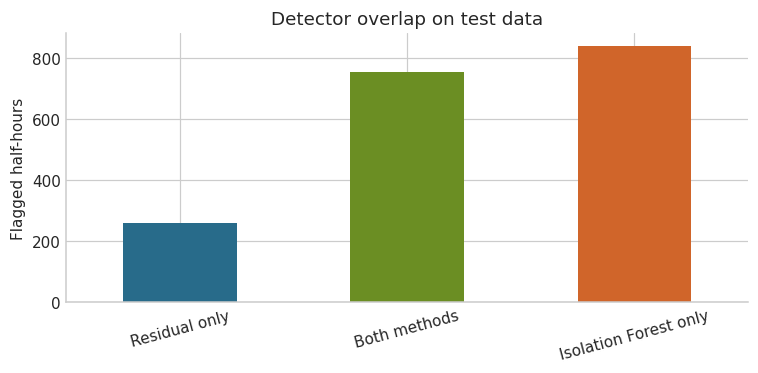

In [12]:
isolation_features = ['residual', 'absolute_error', 'actual_consumption', 'slot', 'day_of_week']
isolation_model = make_pipeline(
    StandardScaler(),
    IsolationForest(n_estimators=200, contamination=.01, random_state=42, n_jobs=-1),
)
isolation_model.fit(scored.loc[scored.split.eq('validation'), isolation_features])
scored['isolation_score'] = -isolation_model.decision_function(scored[isolation_features])
scored['isolation_is_anomaly'] = isolation_model.predict(scored[isolation_features]) == -1

test = scored.loc[scored.split.eq('test')]
overlap = pd.Series({
    'Residual only': (test.is_anomaly & ~test.isolation_is_anomaly).sum(),
    'Both methods': (test.is_anomaly & test.isolation_is_anomaly).sum(),
    'Isolation Forest only': (~test.is_anomaly & test.isolation_is_anomaly).sum(),
})
display(overlap.to_frame('test points'))
print('Isolation Forest test rate:', test.isolation_is_anomaly.mean())
print('Overlap among residual alerts:', overlap['Both methods'] / test.is_anomaly.sum())

overlap.plot.bar(figsize=(7, 3.5), color=['#286b8a', '#6b8e23', '#d0652a'])
plt.title('Detector overlap on test data')
plt.ylabel('Flagged half-hours')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES / 'anomaly_07_isolation_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

Isolation Forest flags more test points. It overlaps with 74.4% of residual alerts but is harder to explain. The robust residual score stays the main method.

## 9. Save results

Keep point-level results for ranking and episode-level results for the future dashboard.

In [13]:
output_columns = [
    'household_id', 'timestamp', 'actual_consumption', 'predicted_consumption',
    'residual', 'absolute_error', 'anomaly_score', 'is_anomaly',
    'anomaly_direction', 'split', 'slot', 'day_of_week', 'weekend',
    'global_is_anomaly', 'isolation_score', 'isolation_is_anomaly',
]
scored[output_columns].to_parquet(PROCESSED / 'anomaly_results.parquet', index=False)
episodes.to_parquet(PROCESSED / 'anomaly_episodes.parquet', index=False)
calibration.to_csv(OUTPUTS / 'anomaly_calibration.csv', index=False)
threshold_comparison.to_csv(OUTPUTS / 'anomaly_threshold_comparison.csv', index=False)

test = scored.loc[scored.split.eq('test')]
test_episodes = episodes.loc[episodes.split.eq('test')]
metrics = {
    'method': 'household robust residual score',
    'score': 'abs(residual - validation household median) / (1.4826 * validation household MAD)',
    'calibration_period': '2013-09-01 to 2013-10-31',
    'application_period': '2013-11-01 to 2013-12-31',
    'selected_expected_validation_alert_rate': .005,
    'selected_threshold': selected_threshold,
    'validation_alert_rate': scored.loc[scored.split.eq('validation'), 'is_anomaly'].mean(),
    'test_alert_rate': test.is_anomaly.mean(),
    'test_flagged_points': int(test.is_anomaly.sum()),
    'test_positive_points': int((test.is_anomaly & test.residual.ge(0)).sum()),
    'test_negative_points': int((test.is_anomaly & test.residual.lt(0)).sum()),
    'test_episodes': len(test_episodes),
    'test_multi_point_episodes': int(test_episodes.duration_slots.gt(1).sum()),
    'isolation_forest_test_alert_rate': test.isolation_is_anomaly.mean(),
    'test_overlap_points': int((test.is_anomaly & test.isolation_is_anomaly).sum()),
    'overlap_share_of_residual_flags': (test.is_anomaly & test.isolation_is_anomaly).sum() / test.is_anomaly.sum(),
    'claim': 'Candidates are unusual deviations, not confirmed anomalies.',
}
(OUTPUTS / 'anomaly_metrics.json').write_text(json.dumps(metrics, indent=2))
display(pd.Series(metrics).to_frame('value'))

,value
method,household robust residual score
score,abs(residual - validation household median) / ...
calibration_period,2013-09-01 to 2013-10-31
application_period,2013-11-01 to 2013-12-31
selected_expected_validation_alert_rate,0.0050
selected_threshold,18.4176
validation_alert_rate,0.0050
test_alert_rate,0.0151
test_flagged_points,1014
test_positive_points,979


## Final choice

Use the household robust residual score with a threshold calibrated at 0.5% on validation. On test, it flags **1.51%** of points: 979 higher and 35 lower than expected, grouped into 566 episodes.

The detector ranks unusual forecast deviations. It cannot confirm their cause without labels or more context.

## Next step

Cost optimization can use the forecast profile. Anomaly flags should stay visible as context and should not automatically change consumption or prices.